# Experiment 1 - W-estimate skill summary

Five presentation figures built from `data/metrics.csv` and the per-cell arrays saved by `run_experiment.py`. Every metric is a plain descriptive statistic (RMS, RMS normalized by the signal std, correlation, bias) - no thresholds or 'best config' judgements are baked in; those are left to discuss.

Run in place after `run_experiment.py` has populated `data/`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = "/home/edavenport/analysis/tpose24-osse"
HERE = os.path.join(REPO, "experiment_1")
sys.path.insert(0, REPO)
import osse_tools as ot

DATA   = os.path.join(HERE, "data")
SUMDIR = os.path.join(HERE, "summary_figs"); os.makedirs(SUMDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120

m = pd.read_csv(os.path.join(DATA, "metrics.csv"))
FAM_COLORS = {"shift": "C0", "equator": "C1", "density": "C2"}

def load_cell(row):
    """Open the saved w_est/w_model/bias arrays for one metrics row."""
    return xr.open_dataset(os.path.join(HERE, row.nc_path))

print(f"{len(m)} config cells across {m.config.nunique()} configs")
m.head()

84 config cells across 48 configs


,config,family,pattern,width,center_lat,n_gliders_cell,n_gliders_total,cell_height_deg,min_depth,max_depth,nc_path,rms,mean_bias,corr,w_est_std,w_model_std,norm_rms,n
0,density_2g_w0.25,density,density_2g,0.25,0.5,2,2,1.0,8,70,data/density_2g_w0.25__cell_+0.50.nc,0.000027,-3.785868e-06,0.916948,0.000053,0.000065,0.413177,20736
1,density_2g_w0.5,density,density_2g,0.50,0.5,2,2,1.0,8,70,data/density_2g_w0.5__cell_+0.50.nc,0.000024,-3.773345e-06,0.936226,0.000047,0.000060,0.391665,20736
2,density_2g_w0.75,density,density_2g,0.75,0.5,2,2,1.0,8,70,data/density_2g_w0.75__cell_+0.50.nc,0.000023,-1.613573e-06,0.926771,0.000044,0.000056,0.401607,20736
3,density_2g_w1.0,density,density_2g,1.00,0.5,2,2,1.0,8,70,data/density_2g_w1.0__cell_+0.50.nc,0.000025,-8.383245e-07,0.892178,0.000043,0.000053,0.462170,20736
4,density_2g_w1.5,density,density_2g,1.50,0.5,2,2,1.0,8,70,data/density_2g_w1.5__cell_+0.50.nc,0.000027,2.477612e-07,0.839144,0.000042,0.000050,0.544032,20736


## Figure 1 - skill overview (is the estimate good enough?)

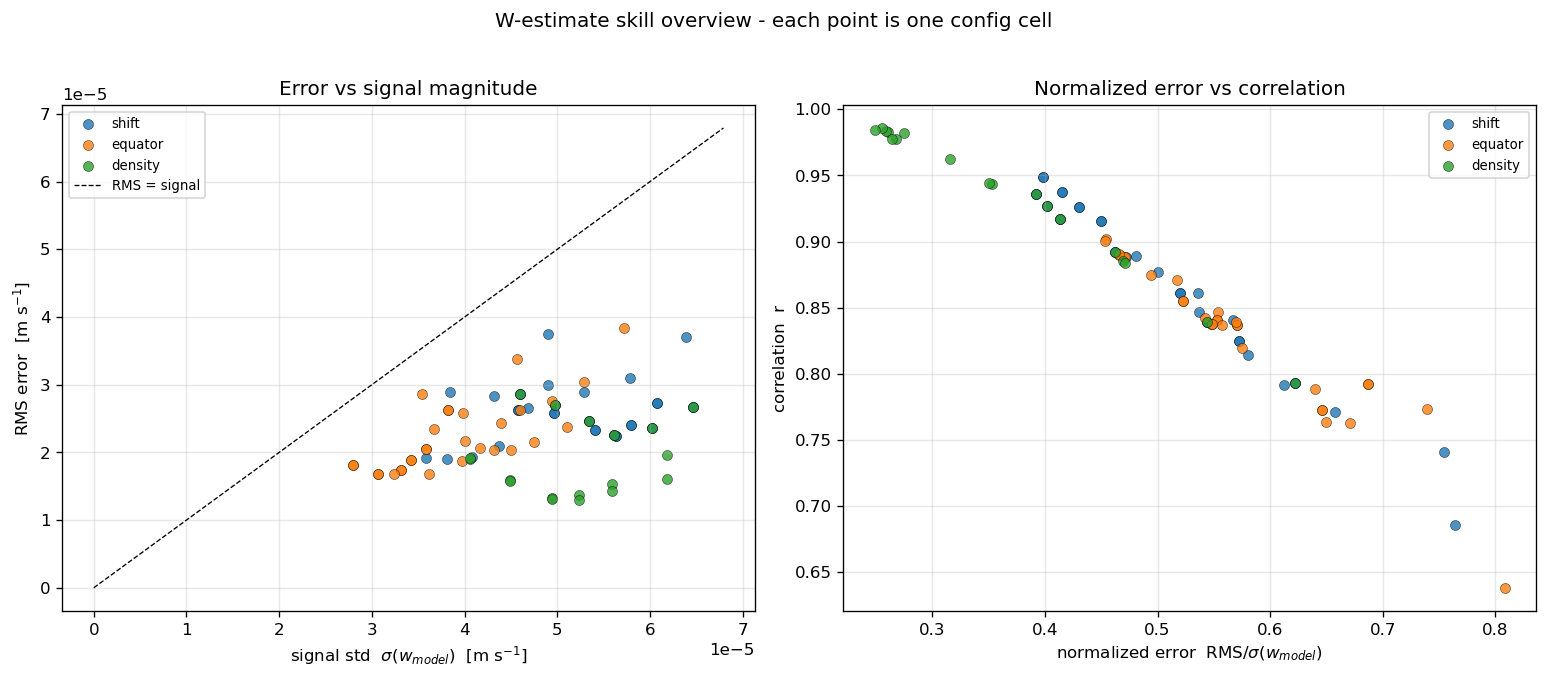

In [2]:
# Figure 1 - skill overview. Each point is one config cell.
# Left: error vs the signal it estimates (dashed = error equals signal).
# Right: normalized error vs correlation. No thresholds applied - for discussion.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for fam, c in FAM_COLORS.items():
    s = m[m.family == fam]
    axes[0].scatter(s.w_model_std, s.rms, c=c, label=fam, alpha=0.8, edgecolor="k", lw=0.3)
    axes[1].scatter(s.norm_rms, s["corr"], c=c, label=fam, alpha=0.8, edgecolor="k", lw=0.3)
hi = float(max(m.w_model_std.max(), m.rms.max())) * 1.05
axes[0].plot([0, hi], [0, hi], "k--", lw=0.8, label="RMS = signal")
axes[0].set_xlabel(r"signal std  $\sigma(w_{model})$  [m s$^{-1}$]")
axes[0].set_ylabel(r"RMS error  [m s$^{-1}$]")
axes[0].set_title("Error vs signal magnitude")
axes[1].set_xlabel(r"normalized error  RMS/$\sigma(w_{model})$")
axes[1].set_ylabel("correlation  r")
axes[1].set_title("Normalized error vs correlation")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("W-estimate skill overview - each point is one config cell", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig1_skill_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 - skill vs array width

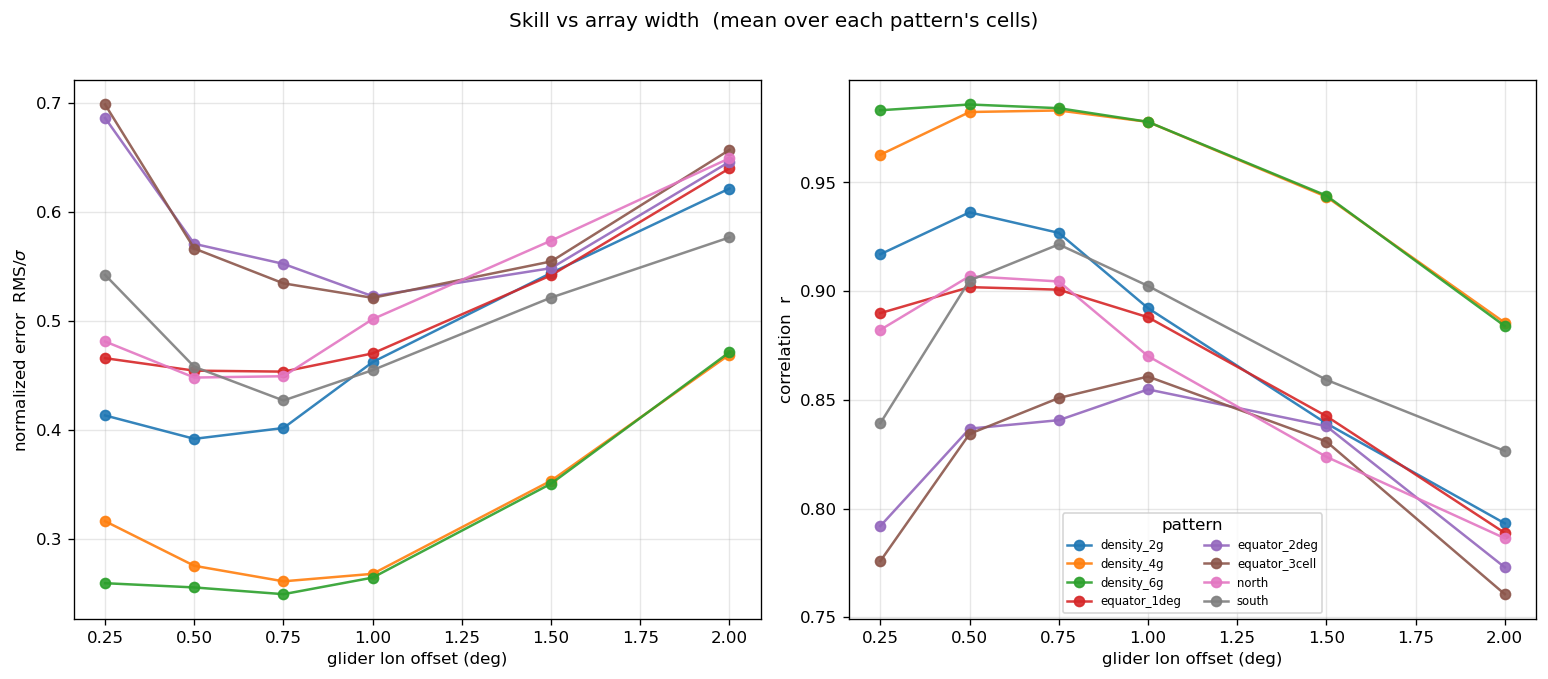

In [3]:
# Figure 2 - skill vs array width, one line per pattern (mean over that pattern's cells).
g = m.groupby(["family", "pattern", "width"], as_index=False)[["norm_rms", "corr"]].mean()
pats = list(g.sort_values(["family", "pattern"])["pattern"].unique())
pat_color = {p: plt.cm.tab10(i % 10) for i, p in enumerate(pats)}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for pat in pats:
    d = g[g.pattern == pat].sort_values("width")
    axes[0].plot(d.width, d.norm_rms, "o-", color=pat_color[pat], alpha=0.9)
    axes[1].plot(d.width, d["corr"], "o-", color=pat_color[pat], alpha=0.9, label=pat)
axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1].set_ylabel("correlation  r")
for ax in axes:
    ax.set_xlabel("glider lon offset (deg)"); ax.grid(alpha=0.3)
axes[1].legend(fontsize=7, ncol=2, title="pattern")
fig.suptitle("Skill vs array width  (mean over each pattern's cells)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig2_skill_vs_width.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 - skill vs latitude

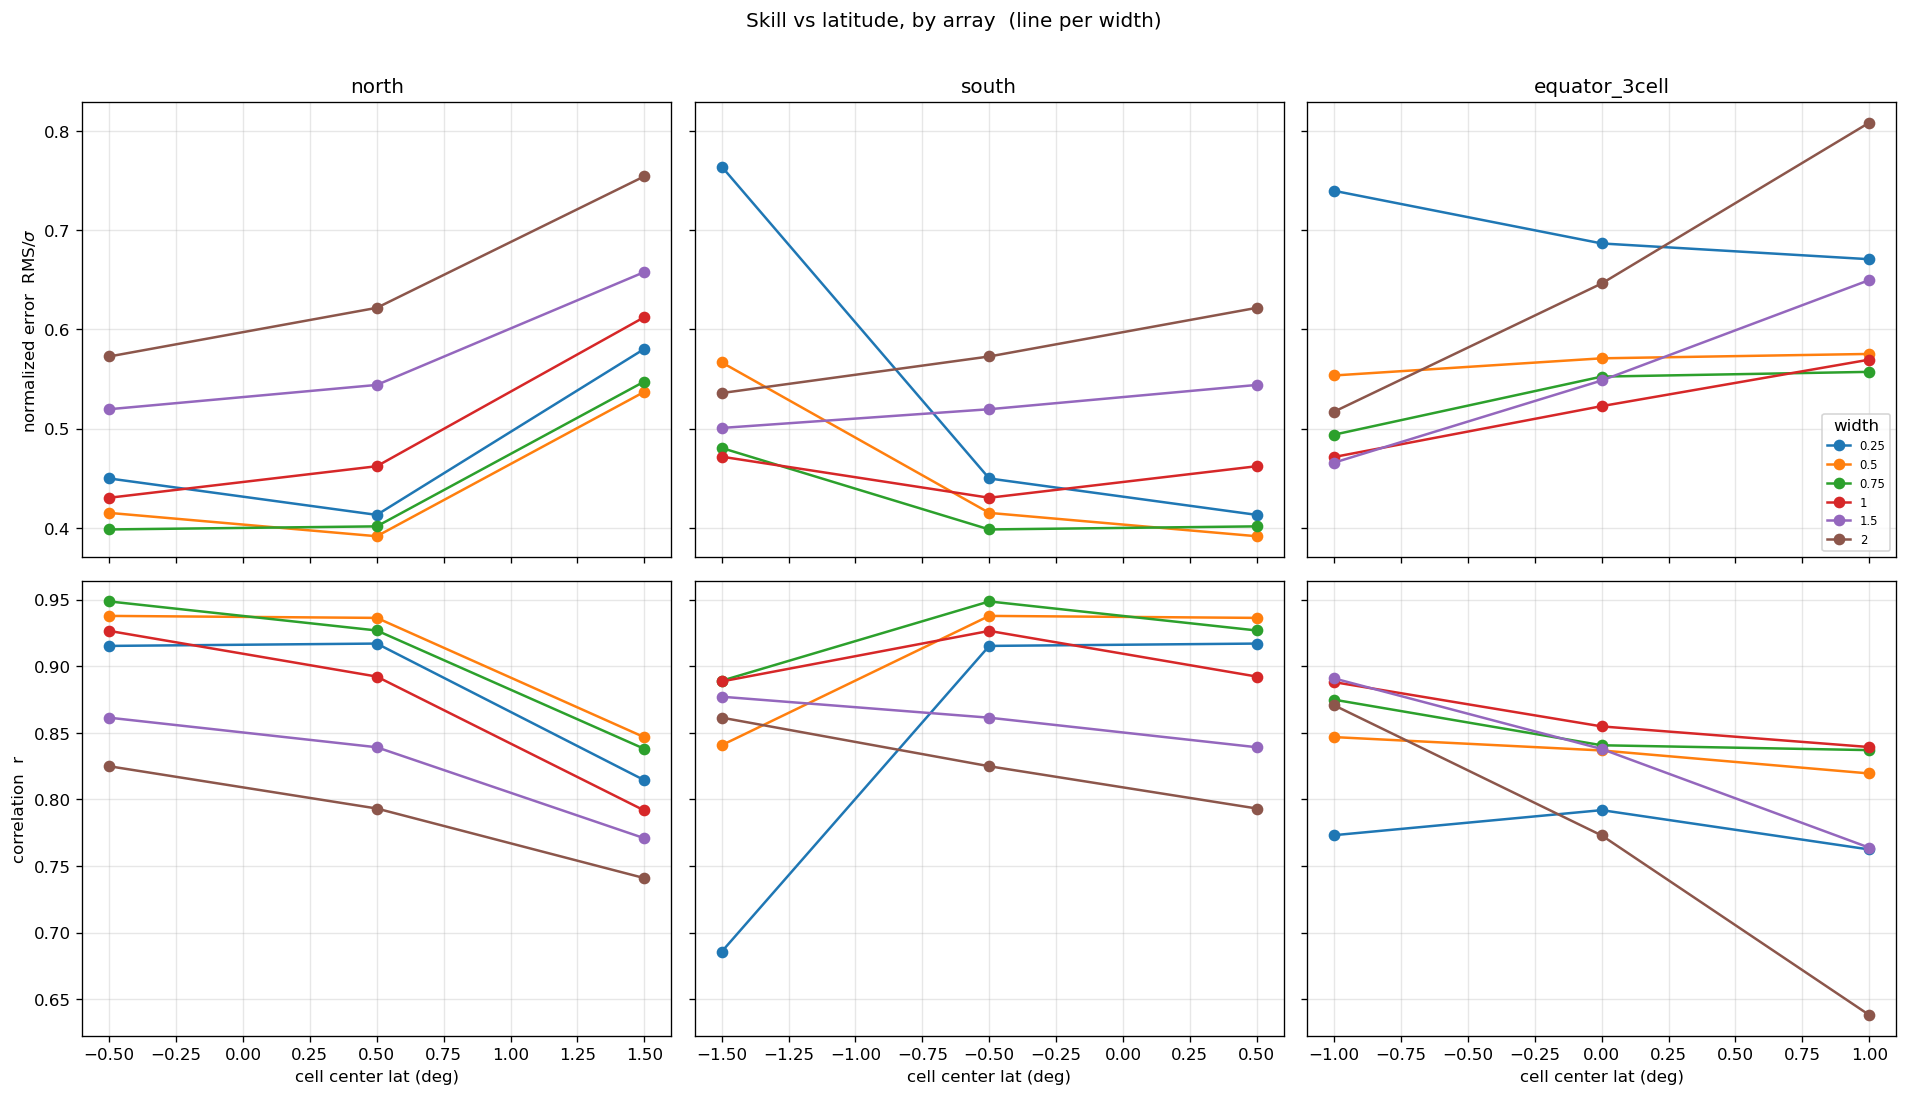

In [4]:
# Figure 3 - skill vs latitude for the multi-latitude arrays, one line per width.
lat_pats = ["north", "south", "equator_3cell"]      # metrics 'pattern' values
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex="col", sharey="row")
for j, pat in enumerate(lat_pats):
    d = m[m.pattern == pat]
    for w, dd in d.groupby("width"):
        dd = dd.sort_values("center_lat")
        axes[0, j].plot(dd.center_lat, dd.norm_rms, "o-", label=f"{w:g}")
        axes[1, j].plot(dd.center_lat, dd["corr"], "o-", label=f"{w:g}")
    axes[0, j].set_title(pat)
    axes[1, j].set_xlabel("cell center lat (deg)")
    for i in (0, 1):
        axes[i, j].grid(alpha=0.3)
axes[0, 0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1, 0].set_ylabel("correlation  r")
axes[0, 2].legend(title="width", fontsize=7)
fig.suptitle("Skill vs latitude, by array  (line per width)", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig3_skill_vs_latitude.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 4 - skill vs gliders-per-cell

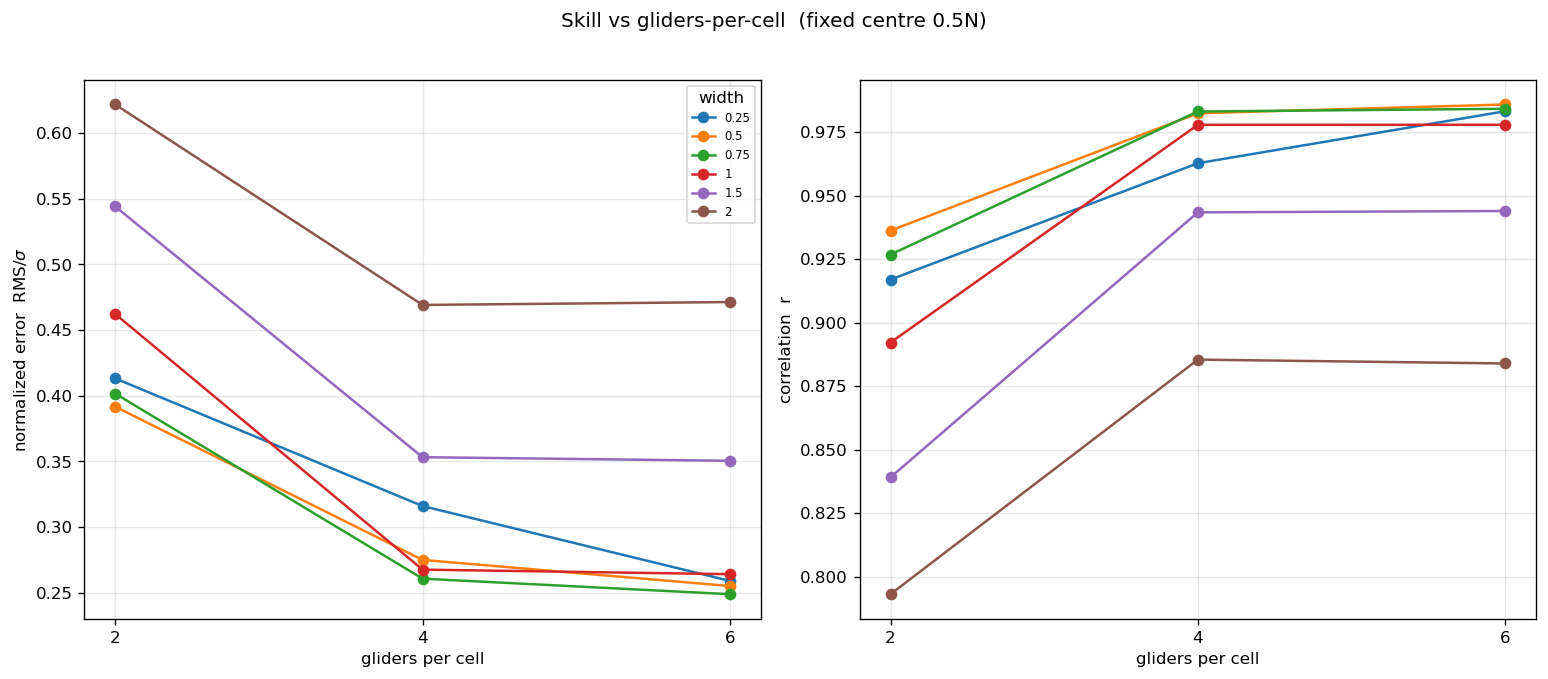

In [5]:
# Figure 4 - skill vs gliders-per-cell at fixed centre 0.5N, one line per width.
d = m[m.family == "density"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for w, dd in d.groupby("width"):
    dd = dd.sort_values("n_gliders_cell")
    axes[0].plot(dd.n_gliders_cell, dd.norm_rms, "o-", label=f"{w:g}")
    axes[1].plot(dd.n_gliders_cell, dd["corr"], "o-", label=f"{w:g}")
axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1].set_ylabel("correlation  r")
for ax in axes:
    ax.set_xlabel("gliders per cell"); ax.set_xticks([2, 4, 6]); ax.grid(alpha=0.3)
axes[0].legend(title="width", fontsize=7)
fig.suptitle("Skill vs gliders-per-cell  (fixed centre 0.5N)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig4_skill_vs_gliders.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 5 - skill vs depth

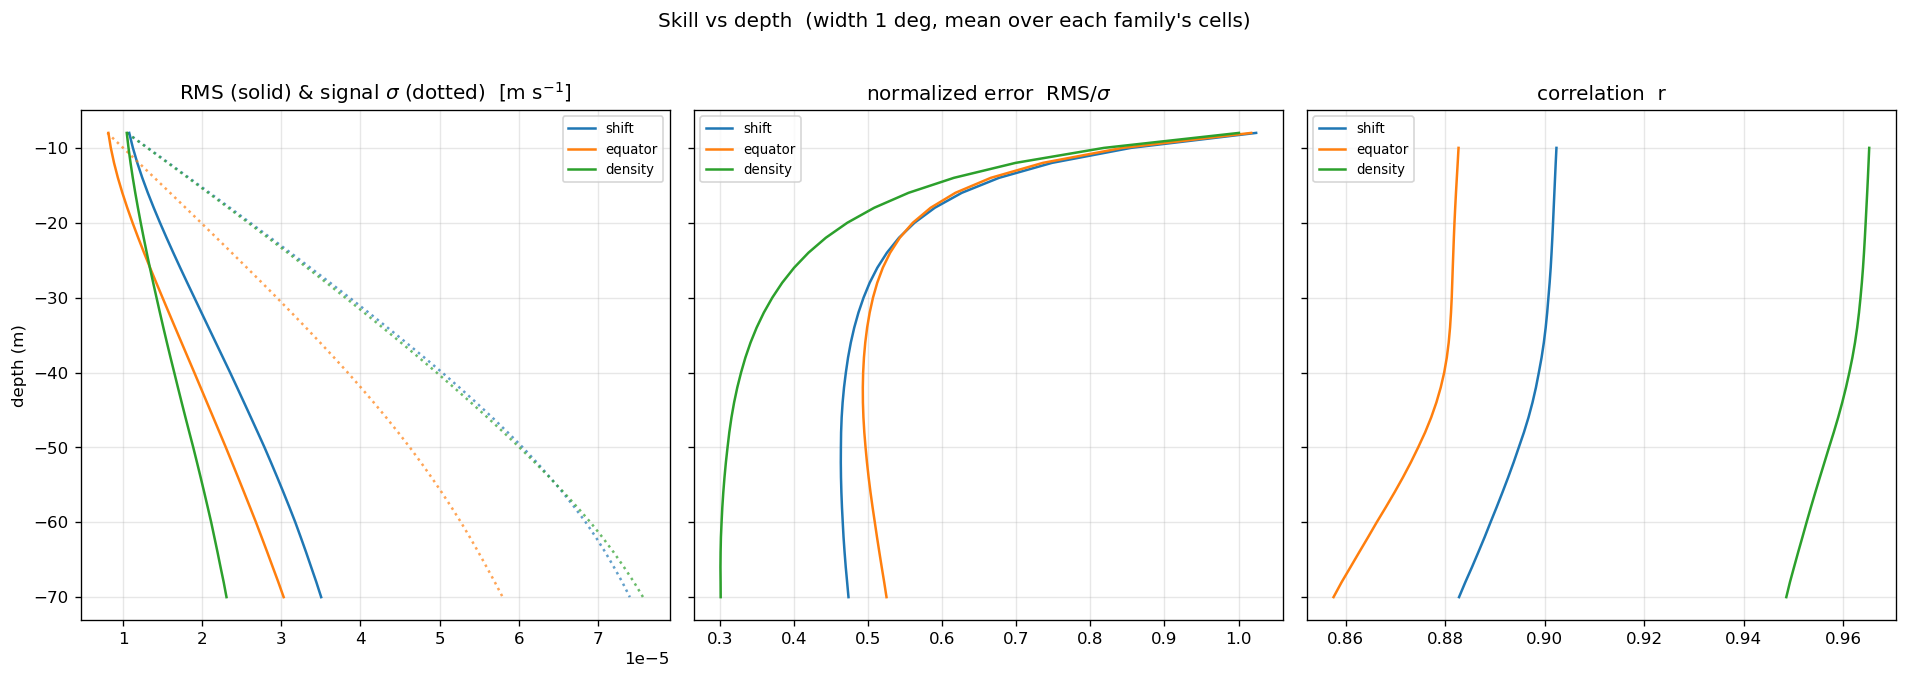

In [6]:
# Figure 5 - skill vs depth within the sampled 8-70 m range, at one width (DEPTH_WIDTH).
# Depth-resolved stats are averaged over each family's cells. Left panel overlays the
# signal std (dotted) so error can be read against the thing being estimated.
DEPTH_WIDTH = 1.0
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
for fam, c in FAM_COLORS.items():
    rows = m[(m.family == fam) & (np.isclose(m.width, DEPTH_WIDTH))]
    bds = [ot.w_skill_by_depth(ds.w_est, ds.w_model)
           for ds in (load_cell(r) for _, r in rows.iterrows())]
    B = xr.concat(bds, dim="cell").mean("cell")
    z = B.depth
    axes[0].plot(B.rms, z, color=c, label=fam)
    axes[0].plot(B.w_model_std, z, color=c, ls=":", alpha=0.7)
    axes[1].plot(B.norm_rms, z, color=c, label=fam)
    axes[2].plot(B["corr"], z, color=c, label=fam)
axes[0].set_title(r"RMS (solid) & signal $\sigma$ (dotted)  [m s$^{-1}$]")
axes[1].set_title(r"normalized error  RMS/$\sigma$")
axes[2].set_title("correlation  r")
axes[0].set_ylabel("depth (m)")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f"Skill vs depth  (width {DEPTH_WIDTH:g} deg, mean over each family's cells)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig5_skill_vs_depth.png"), dpi=150, bbox_inches="tight")
plt.show()